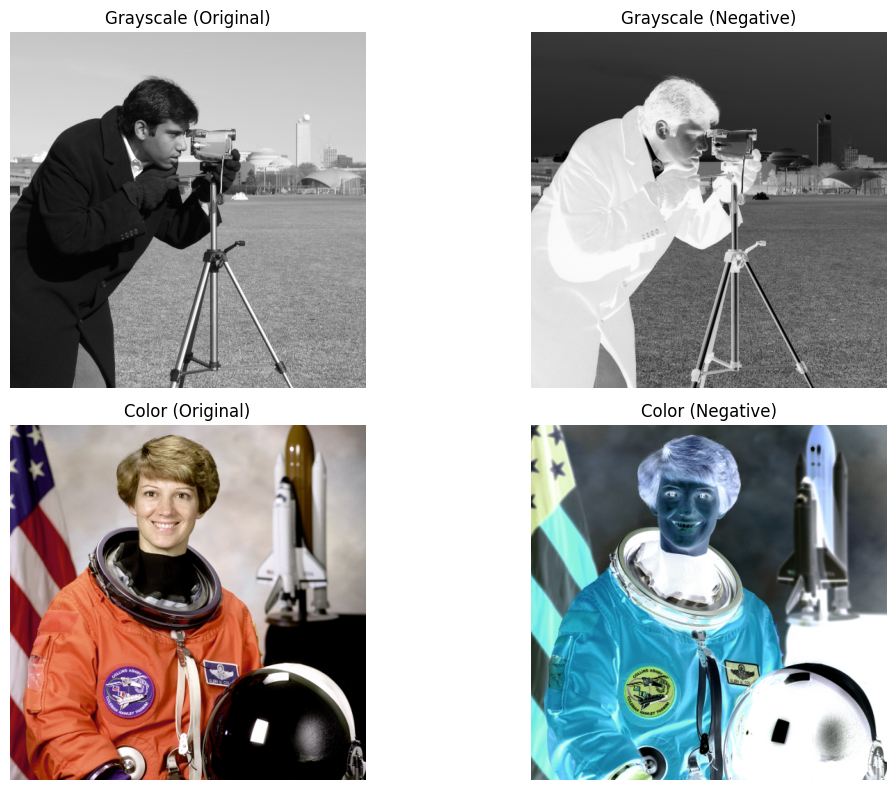

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
image_gray_uint8 = data.camera()                 # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8) # Konversi ke float [0..1]
negative_gray = 1.0 - image_gray_float            # Inversi intensitas: output = 1 - input

# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
image_color_uint8 = data.astronaut()             # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)
negative_color = 1.0 - image_color_float          # Inversi tiap kanal RGB

# 3. PLOTTING HASIL
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].imshow(image_gray_float, cmap='gray'); axes[0, 0].set_title("Grayscale (Original)"); axes[0, 0].axis('off')
axes[0, 1].imshow(negative_gray, cmap='gray');    axes[0, 1].set_title("Grayscale (Negative)"); axes[0, 1].axis('off')
axes[1, 0].imshow(image_color_float);             axes[1, 0].set_title("Color (Original)");     axes[1, 0].axis('off')
axes[1, 1].imshow(negative_color);                axes[1, 1].set_title("Color (Negative)");     axes[1, 1].axis('off')
plt.tight_layout(); plt.show()

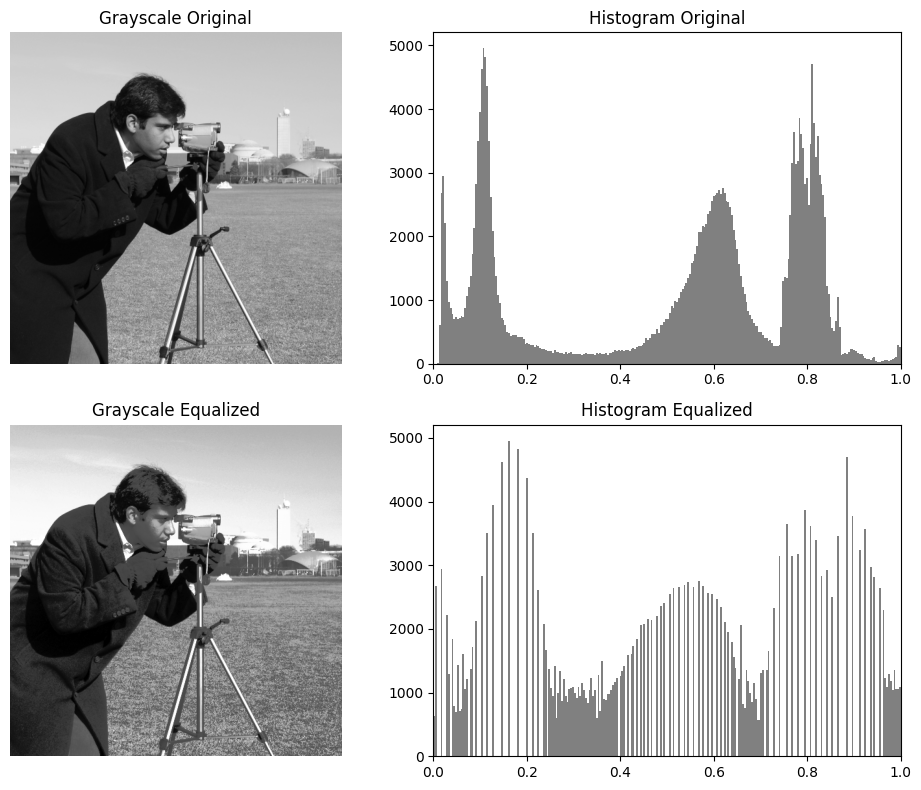

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# BAGIAN 1: GRAYSCALE
image_gray = img_as_float(data.camera())
image_gray_eq = exposure.equalize_hist(image_gray)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(image_gray, cmap='gray'); axes[0, 0].set_title("Grayscale Original"); axes[0, 0].axis('off')
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray'); axes[0, 1].set_title("Histogram Original"); axes[0, 1].set_xlim(0,1)
axes[1, 0].imshow(image_gray_eq, cmap='gray'); axes[1, 0].set_title("Grayscale Equalized"); axes[1, 0].axis('off')
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray'); axes[1, 1].set_title("Histogram Equalized"); axes[1, 1].set_xlim(0,1)
plt.tight_layout(); plt.show()

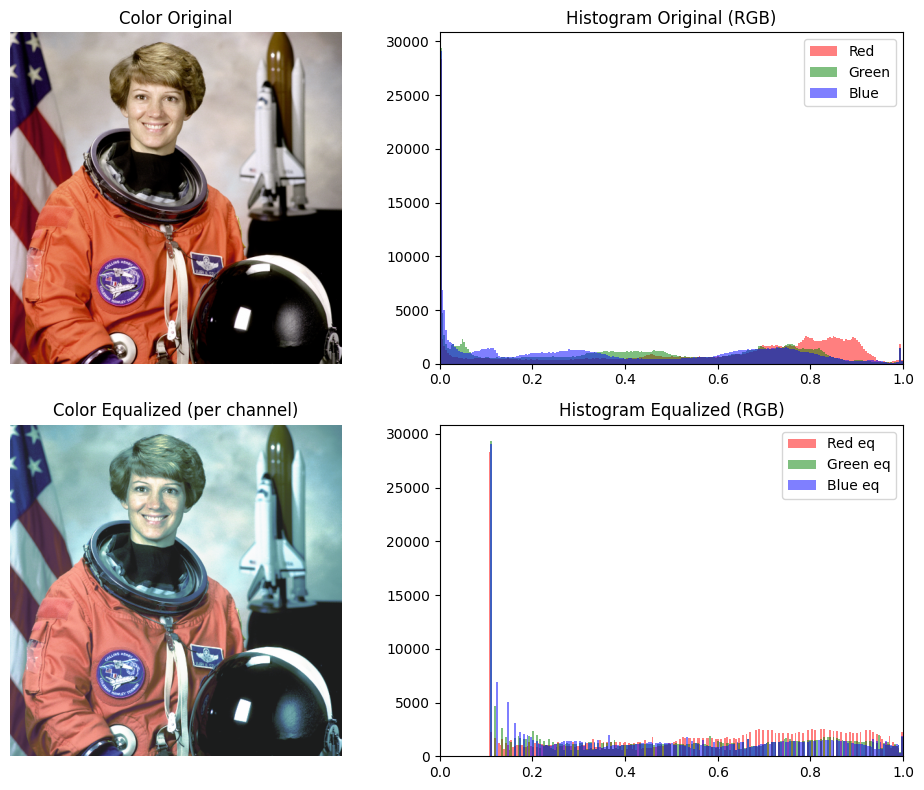

In [3]:
# BAGIAN 2: CITRA BERWARNA (ekualisasi per kanal)
image_color = img_as_float(data.astronaut())
r_channel, g_channel, b_channel = image_color[:,:,0], image_color[:,:,1], image_color[:,:,2]

r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))
axes2[0, 0].imshow(image_color); axes2[0, 0].set_title("Color Original"); axes2[0, 0].axis('off')
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red',   alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue',  alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)"); axes2[0, 1].set_xlim(0,1); axes2[0, 1].legend(loc='upper right')
axes2[1, 0].imshow(image_color_eq); axes2[1, 0].set_title("Color Equalized (per channel)"); axes2[1, 0].axis('off')
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red',   alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue',  alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)"); axes2[1, 1].set_xlim(0,1); axes2[1, 1].legend(loc='upper right')
plt.tight_layout(); plt.show()

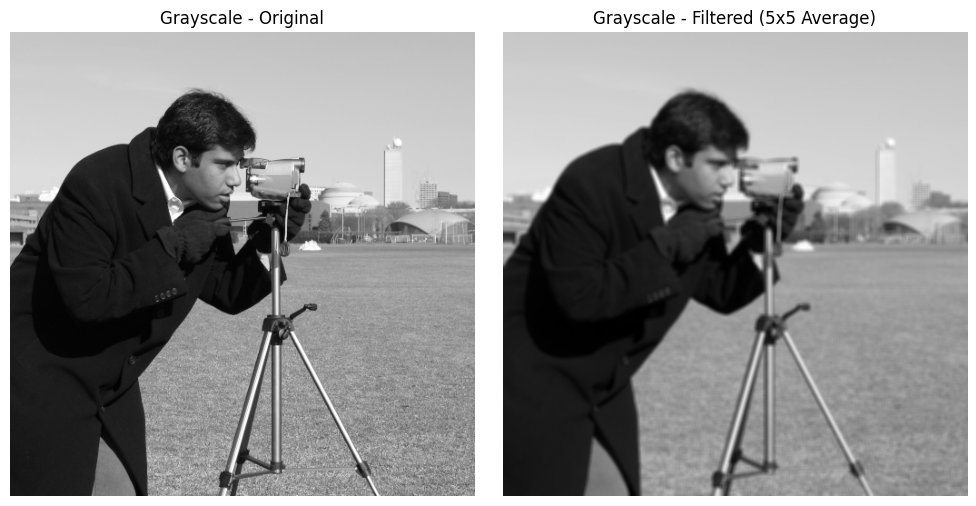

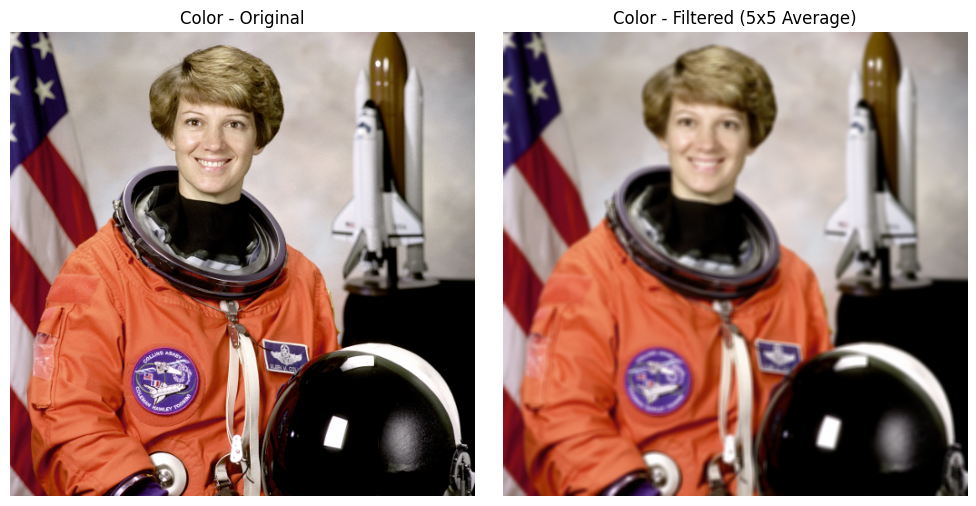

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# 1) GRAYSCALE
gray_img = img_as_float(data.camera())
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray'); axes[0].set_title("Grayscale - Original"); axes[0].axis('off')
axes[1].imshow(gray_filtered, cmap='gray'); axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)"); axes[1].axis('off')
plt.tight_layout(); plt.show()

# 2) BERWARNA (per kanal)
color_img = img_as_float(data.astronaut())
color_filtered = np.zeros_like(color_img)
for c in range(3):
    color_filtered[:, :, c] = ndi.convolve(color_img[:, :, c], kernel, mode='reflect')

fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img); axes2[0].set_title("Color - Original"); axes2[0].axis('off')
axes2[1].imshow(color_filtered); axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)"); axes2[1].axis('off')
plt.tight_layout(); plt.show()

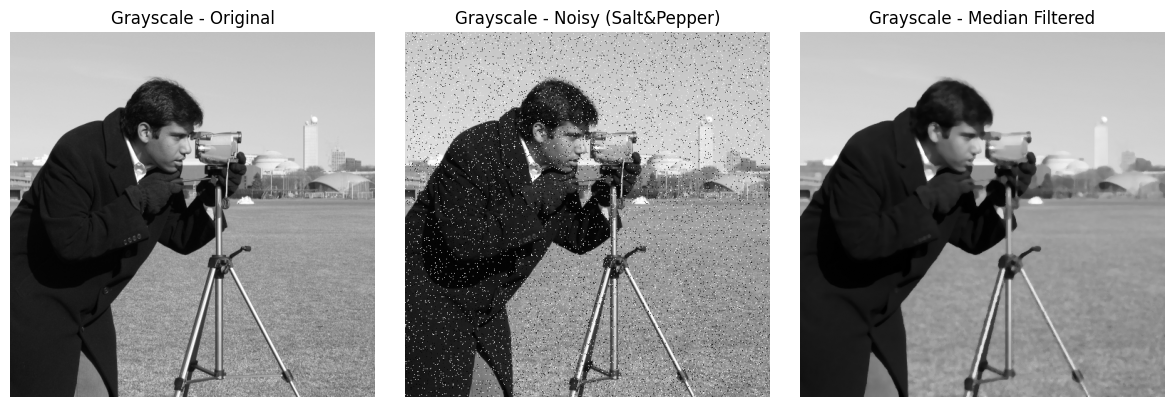

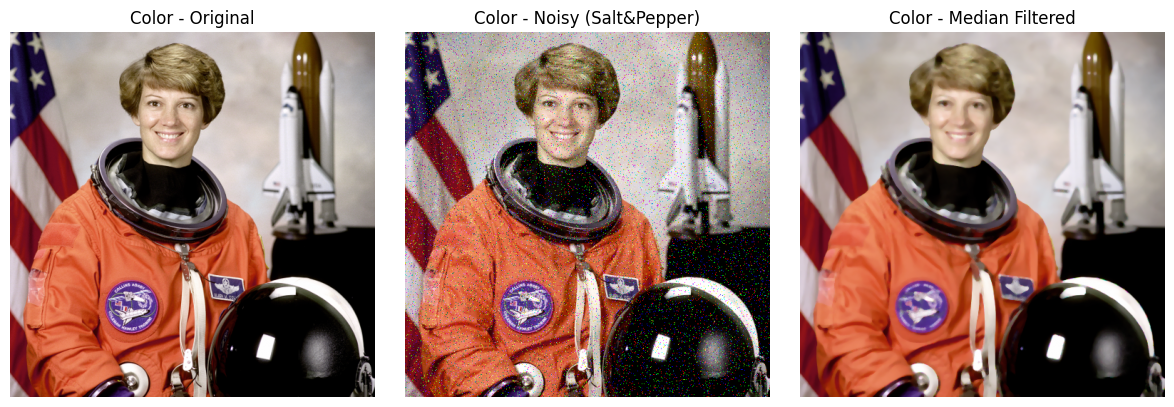

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# 1) GRAYSCALE
gray_float = img_as_float(data.camera())
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)   # 5% piksel terkena noise
gray_denoised = filters.median(gray_noisy, morphology.disk(3))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray'); axes[0].set_title("Grayscale - Original"); axes[0].axis('off')
axes[1].imshow(gray_noisy, cmap='gray'); axes[1].set_title("Grayscale - Noisy (Salt&Pepper)"); axes[1].axis('off')
axes[2].imshow(gray_denoised, cmap='gray'); axes[2].set_title("Grayscale - Median Filtered"); axes[2].axis('off')
plt.tight_layout(); plt.show()

# 2) BERWARNA (per kanal)
color_float = img_as_float(data.astronaut())
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float); axes2[0].set_title("Color - Original"); axes2[0].axis('off')
axes2[1].imshow(color_noisy); axes2[1].set_title("Color - Noisy (Salt&Pepper)"); axes2[1].axis('off')
axes2[2].imshow(color_denoised); axes2[2].set_title("Color - Median Filtered"); axes2[2].axis('off')
plt.tight_layout(); plt.show()